The objective of this analysis is to apply K-means clustering to segment customers into distinct groups based on their purchasing behavior, demographics, and preferences. The goal is to analyze and interpret these clusters in order to derive actionable insights that can inform targeted marketing and sales strategies tailored to key customer segments.

The model is built using the Walmart dataset sourced from Kaggle.

In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import davies_bouldin_score

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv('Walmart.csv')

In [4]:
df.head(5)

,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,...,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand
0,1,2824,843,Fridge,Electronics,3,188.46,3/31/2024 21:46,3,"Miami, FL",...,Silver,Credit Card,True,NaN,Stormy,False,Friday,True,172,179
1,2,1409,135,TV,Electronics,4,1912.04,7/28/2024 12:45,5,"Dallas, TX",...,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484
2,3,5506,391,Fridge,Electronics,4,1377.75,6/10/2024 4:55,1,"Los Angeles, CA",...,Platinum,Cash,False,NaN,Sunny,False,Tuesday,True,289,416
3,4,5012,710,Smartphone,Electronics,5,182.31,8/15/2024 1:03,5,"Miami, FL",...,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446
4,5,4657,116,Laptop,Electronics,3,499.28,9/13/2024 0:45,6,"Chicago, IL",...,Bronze,Digital Wallet,False,NaN,Sunny,False,Thursday,True,287,469


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   product_id              5000 non-null   int64  
 3   product_name            5000 non-null   object 
 4   category                5000 non-null   object 
 5   quantity_sold           5000 non-null   int64  
 6   unit_price              5000 non-null   float64
 7   transaction_date        5000 non-null   object 
 8   store_id                5000 non-null   int64  
 9   store_location          5000 non-null   object 
 10  inventory_level         5000 non-null   int64  
 11  reorder_point           5000 non-null   int64  
 12  reorder_quantity        5000 non-null   int64  
 13  supplier_id             5000 non-null   int64  
 14  supplier_lead_time      5000 non-null   

In [6]:
#Convert null values to 'none'
df['promotion_type'] = df['promotion_type'].fillna('none')

In [7]:
#Use the transaction_date column to calculate time_between_purchases
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df = df.sort_values(by=['customer_id', 'transaction_date'])
df['time_between_purchases'] = df.groupby('customer_id')['transaction_date'].diff().dt.days
df['time_between_purchases'] = df['time_between_purchases'].fillna(0).astype(int)

In [8]:
#Drop columns unrelated to customer demographics
df_new = df.drop(['transaction_date','transaction_id','customer_id','inventory_level','reorder_point',
                  'reorder_quantity','supplier_id','supplier_lead_time','stockout_indicator','forecasted_demand',
                  'product_id','product_name','category','quantity_sold','unit_price','actual_demand','store_id',
                  'weather_conditions','weekday'],axis=1)

In [9]:
df_new.head(5)

,store_location,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,holiday_indicator,time_between_purchases
4724,"Miami, FL",28,Male,108878.42,Bronze,Debit Card,True,none,False,0
3832,"Los Angeles, CA",22,Other,60155.52,Bronze,Cash,True,none,False,0
4999,"New York, NY",53,Other,95114.01,Platinum,Debit Card,True,BOGO,True,0
4439,"Los Angeles, CA",28,Male,48424.97,Bronze,Credit Card,True,none,False,0
428,"Los Angeles, CA",65,Other,30309.71,Silver,Digital Wallet,True,BOGO,True,0


In [10]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 4724 to 837
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   store_location          5000 non-null   object 
 1   customer_age            5000 non-null   int64  
 2   customer_gender         5000 non-null   object 
 3   customer_income         5000 non-null   float64
 4   customer_loyalty_level  5000 non-null   object 
 5   payment_method          5000 non-null   object 
 6   promotion_applied       5000 non-null   bool   
 7   promotion_type          5000 non-null   object 
 8   holiday_indicator       5000 non-null   bool   
 9   time_between_purchases  5000 non-null   int32  
dtypes: bool(2), float64(1), int32(1), int64(1), object(5)
memory usage: 244.1+ KB


In [11]:
# One-Hot Encode categorical variables
encoder = OneHotEncoder(sparse_output=False)

columns_to_encode = df_new[['store_location','customer_gender','customer_loyalty_level',
                            'payment_method','promotion_type']]

encoded_columns = encoder.fit_transform(columns_to_encode)

encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out())

df_encoded = pd.concat([df_new.drop(columns_to_encode,axis=1), encoded_df], axis=1)


In [12]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 4724 to 837
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   customer_age                        5000 non-null   int64  
 1   customer_income                     5000 non-null   float64
 2   promotion_applied                   5000 non-null   bool   
 3   holiday_indicator                   5000 non-null   bool   
 4   time_between_purchases              5000 non-null   int32  
 5   store_location_Chicago, IL          5000 non-null   float64
 6   store_location_Dallas, TX           5000 non-null   float64
 7   store_location_Los Angeles, CA      5000 non-null   float64
 8   store_location_Miami, FL            5000 non-null   float64
 9   store_location_New York, NY         5000 non-null   float64
 10  customer_gender_Female              5000 non-null   float64
 11  customer_gender_Male                5000 non-n

In [13]:
#Create a copy of the data frame and scale data to prepare for KMeans modeling
df_scaled = df_encoded.copy()
numeric_columns = df_scaled.select_dtypes(include=['int64', 'int32']).columns
df_scaled[numeric_columns] = MinMaxScaler().fit_transform(df_scaled[numeric_columns])

In [14]:
df_scaled.head(5)

,customer_age,customer_income,promotion_applied,holiday_indicator,time_between_purchases,"store_location_Chicago, IL","store_location_Dallas, TX","store_location_Los Angeles, CA","store_location_Miami, FL","store_location_New York, NY",...,customer_loyalty_level_Gold,customer_loyalty_level_Platinum,customer_loyalty_level_Silver,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_Digital Wallet,promotion_type_BOGO,promotion_type_Percentage Discount,promotion_type_none
4724,0.192308,108878.42,True,False,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3832,0.076923,60155.52,True,False,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4999,0.673077,95114.01,True,True,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4439,0.192308,48424.97,True,False,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
428,0.903846,30309.71,True,True,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [15]:
#Create a function that fits a KMeans model for multiple values of K and calculates the inertia score for each value of K
num_clusters = [i for i in range(2,11)]
def KMeans_inertia(num_clusters,x_vals):
    inertia = []
    for num in num_clusters:
        kms = KMeans(n_clusters = num,random_state = 42)
        kms.fit(x_vals)
        inertia.append(kms.inertia_)
    return inertia
inertia = KMeans_inertia(num_clusters,df_scaled)
inertia

[1068919110587.5225,
 457124671332.29016,
 260902375170.00433,
 163807887603.5493,
 114830151697.09691,
 84083754211.37305,
 63043530538.52496,
 51891813874.76939,
 41554264289.94993]

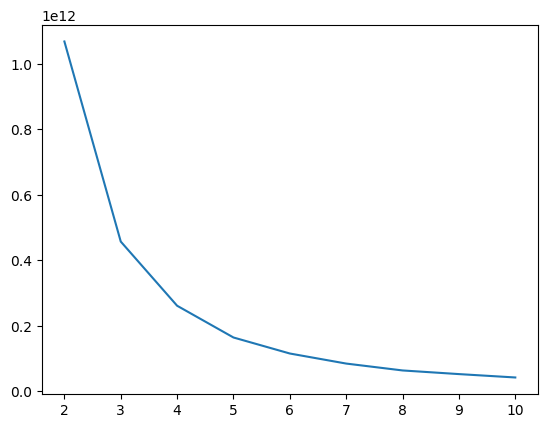

In [16]:
#Create an elbow plot with the inertia values
inertia_plot = sns.lineplot(x=num_clusters,y=inertia)

The elbow in the plot appears to level off between k values of 3 and 5. To further refine the determination of the optimal number of clusters, I will calculate the Davies-Bouldin index within this range.

In [17]:
#Create a function that fits a KMeans model for multiple values of K and calculates the Davies-Bouldin index for each value of K
num_clusters = [i for i in range(3,5)]
def KMeans_dbi(num_clusters,x_vals):
    dbi = []
    for num in num_clusters:
        kms = KMeans(n_clusters = num,random_state = 42)
        kms.fit(x_vals)
        dbi.append(davies_bouldin_score(x_vals, kms.labels_))
    return dbi
dbi = KMeans_dbi(num_clusters,df_scaled)

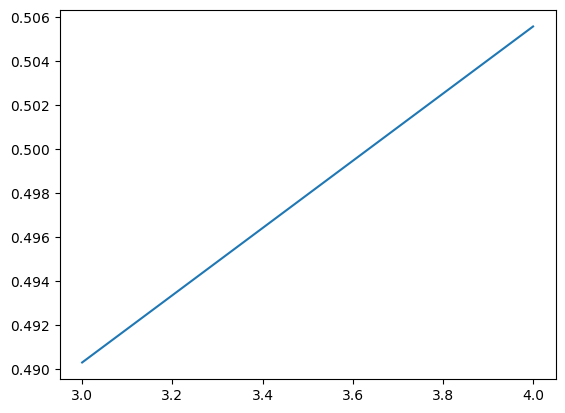

In [18]:
plot = sns.lineplot(x=num_clusters,y=dbi)

Based on the analysis of both the elbow plot of inertia scores and the plot of Davies-Bouldin indices, k=3 has been identified as the optimal number of clusters. I will now proceed to fit a KMeans model with n_clusters = 3 and conduct a detailed analysis of the purchasing behavior, demographics, and preferences associated with the three identified clusters.

In [19]:
kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans3.fit(df_scaled)

KMeans(n_clusters=3, random_state=42)

In [20]:
#Calculate Davies-Bouldin score for n_clusters = 3
dbi_kmeans3 = davies_bouldin_score(df_scaled, kmeans3.labels_)
print(f'Davies-Bouldin Index: {dbi}')

Davies-Bouldin Index: [np.float64(0.490312930950121), np.float64(0.5055702589665673)]


The low Davies-Bouldin score of approximately 0.5 indicates a well-defined clustering structure. I will now assign cluster labels to the dataframe and initiate the analysis of customer behavior based on cluster membership.

In [21]:
#Create a new column that indicates the cluster assignments
df_encoded['cluster'] = kmeans3.labels_
df_encoded.head(5)

,customer_age,customer_income,promotion_applied,holiday_indicator,time_between_purchases,"store_location_Chicago, IL","store_location_Dallas, TX","store_location_Los Angeles, CA","store_location_Miami, FL","store_location_New York, NY",...,customer_loyalty_level_Platinum,customer_loyalty_level_Silver,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card,payment_method_Digital Wallet,promotion_type_BOGO,promotion_type_Percentage Discount,promotion_type_none,cluster
4724,28,108878.42,True,False,0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3832,22,60155.52,True,False,0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1
4999,53,95114.01,True,True,0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4439,28,48424.97,True,False,0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2
428,65,30309.71,True,True,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2


In [22]:
#Determine the most important features for clustering. The larger the difference between centroids, the more important the feature is
centroids = pd.DataFrame(kmeans3.cluster_centers_, columns=df_scaled.columns)

importance = centroids.diff(axis=0).iloc[1].abs()
importance = importance.sort_values(ascending=False)

print("\nMost Important Features for Clustering:")
print(importance)


Most Important Features for Clustering:
customer_income                       33479.103207
promotion_type_none                       0.030942
holiday_indicator                         0.025839
customer_loyalty_level_Gold               0.025020
payment_method_Credit Card                0.023064
promotion_type_Percentage Discount        0.022732
customer_loyalty_level_Platinum           0.019592
customer_gender_Other                     0.015378
payment_method_Debit Card                 0.012856
customer_gender_Male                      0.012752
customer_loyalty_level_Silver             0.011786
payment_method_Digital Wallet             0.011766
store_location_New York, NY               0.010974
time_between_purchases                    0.008745
promotion_type_BOGO                       0.008211
store_location_Dallas, TX                 0.007688
customer_loyalty_level_Bronze             0.006358
store_location_Miami, FL                  0.005255
customer_age                             

Customer income has been identified as the primary factor driving the formation of clusters. The next phase will involve a detailed analysis of the specific features that define each cluster. To facilitate this, I will create a new DataFrame by decoding the one-hot encoded variables and subsequently concatenate it with relevant variables from the original dataset. This approach will provide a starting point for further analysis.

In [23]:
#Decode one-hot encoded categorical variables back to their original categories
def decode_multiple_categorical(df_encoded, prefix_dict):
    df_decoded = df_encoded.copy()
    for column, prefix in prefix_dict.items():
        relevant_columns = [col for col in df_encoded.columns if col.startswith(prefix)]
        df_decoded[column + '_decoded'] = df_encoded[relevant_columns].idxmax(axis=1)
        df_decoded[column + '_decoded'] = df_decoded[column + '_decoded'].str.replace(prefix, '', regex=False)
    return df_decoded

prefix_dict = {
    'store_location_Chicago, IL': 'store_location_',
    'store_location_Dallas, TX': 'store_location_',
    'store_location_Los Angeles, CA': 'store_location_',
    'store_location_Miami, FL': 'store_location_',
    'store_location_New York, NY': 'store_location_',
    'customer_gender_Female': 'customer_gender_',
    'customer_gender_Male': 'customer_gender_',
    'customer_gender_Other': 'customer_gender_',
    'customer_loyalty_level_Bronze': 'customer_loyalty_level_',
    'customer_loyalty_level_Gold': 'customer_loyalty_level_',
    'customer_loyalty_level_Silver': 'customer_loyalty_level_',
    'customer_loyalty_level_Platinum': 'customer_loyalty_level_',
    'payment_method_Cash': 'payment_method_',
    'payment_method_Credit Card': 'payment_method_',
    'payment_method_Debit Card': 'payment_method_',
    'payment_method_Digital Wallet': 'payment_method_',
    'promotion_type_BOGO': 'promotion_type_',
    'promotion_type_Percentage Discount': 'promotion_type_',
    'promotion_type_none': 'promotion_type_'
}

df_decoded = decode_multiple_categorical(df_encoded, prefix_dict)

selected_columns = ['cluster','customer_age','customer_income','promotion_applied','holiday_indicator',
                    'time_between_purchases','store_location_Chicago, IL_decoded','customer_gender_Female_decoded',
                    'customer_loyalty_level_Bronze_decoded','payment_method_Cash_decoded','promotion_type_BOGO_decoded']
df_decoded_new = df_decoded[selected_columns]
df_decoded_new = df_decoded_new.rename(columns={'store_location_Chicago, IL_decoded': 'store_location', 
                                                 'customer_gender_Female_decoded': 'customer_gender',
                                                'customer_loyalty_level_Bronze_decoded':'customer_loyalty_level',
                                                'payment_method_Cash_decoded':'payment_method',
                                                'promotion_type_BOGO_decoded':'promotion_type'})
df_decoded_new.head(5)

,cluster,customer_age,customer_income,promotion_applied,holiday_indicator,time_between_purchases,store_location,customer_gender,customer_loyalty_level,payment_method,promotion_type
4724,0,28,108878.42,True,False,0,"Chicago, IL",Male,Silver,Cash,Percentage Discount
3832,1,22,60155.52,True,False,0,"Miami, FL",Female,Bronze,Digital Wallet,none
4999,0,53,95114.01,True,True,0,"New York, NY",Male,Silver,Cash,none
4439,2,28,48424.97,True,False,0,"New York, NY",Other,Gold,Credit Card,none
428,2,65,30309.71,True,True,0,"Los Angeles, CA",Other,Bronze,Debit Card,none


In [24]:
#Select columns from the original dataframe to prepare to concatenate 
selected_columns_df = ['product_id','product_name','category','quantity_sold','unit_price','store_id','weather_conditions',
                       'weekday']
df_edit = df[selected_columns_df]
df_edit.head(5)

,product_id,product_name,category,quantity_sold,unit_price,store_id,weather_conditions,weekday
4724,231,Laptop,Electronics,1,990.27,13,Rainy,Monday
3832,408,Headphones,Electronics,3,1647.29,7,Stormy,Saturday
4999,926,Washing Machine,Appliances,1,710.03,12,Stormy,Wednesday
4439,949,TV,Electronics,5,1375.81,3,Cloudy,Tuesday
428,115,TV,Appliances,5,1274.48,19,Stormy,Monday


In [25]:
#Combine dataframes
df_combined = pd.concat([df_decoded_new, df_edit], axis=1)
df_combined.head(5)

,cluster,customer_age,customer_income,promotion_applied,holiday_indicator,time_between_purchases,store_location,customer_gender,customer_loyalty_level,payment_method,promotion_type,product_id,product_name,category,quantity_sold,unit_price,store_id,weather_conditions,weekday
4724,0,28,108878.42,True,False,0,"Chicago, IL",Male,Silver,Cash,Percentage Discount,231,Laptop,Electronics,1,990.27,13,Rainy,Monday
3832,1,22,60155.52,True,False,0,"Miami, FL",Female,Bronze,Digital Wallet,none,408,Headphones,Electronics,3,1647.29,7,Stormy,Saturday
4999,0,53,95114.01,True,True,0,"New York, NY",Male,Silver,Cash,none,926,Washing Machine,Appliances,1,710.03,12,Stormy,Wednesday
4439,2,28,48424.97,True,False,0,"New York, NY",Other,Gold,Credit Card,none,949,TV,Electronics,5,1375.81,3,Cloudy,Tuesday
428,2,65,30309.71,True,True,0,"Los Angeles, CA",Other,Bronze,Debit Card,none,115,TV,Appliances,5,1274.48,19,Stormy,Monday


In [26]:
#Create age_bins from customer_age 
bins = [0, 18, 30, 40, 50, 100]
bin_labels = ['0-18', '19-30', '31-40', '41-50', '51+']
df_combined['age_bins'] = pd.cut(df_combined['customer_age'], bins=bins, labels=bin_labels, right=False)

In [27]:
#Create income_bins from customer_income
percentiles = [0, 20, 40, 60, 80, 100]
percentile_bins = pd.qcut(df_combined['customer_income'], q=5, labels=['Low', 'Mid', 'Upper-Mid', 'High', 'Very High'])
df_combined['income_bins'] = percentile_bins
df_combined.head(5)

,cluster,customer_age,customer_income,promotion_applied,holiday_indicator,time_between_purchases,store_location,customer_gender,customer_loyalty_level,payment_method,...,product_id,product_name,category,quantity_sold,unit_price,store_id,weather_conditions,weekday,age_bins,income_bins
4724,0,28,108878.42,True,False,0,"Chicago, IL",Male,Silver,Cash,...,231,Laptop,Electronics,1,990.27,13,Rainy,Monday,19-30,Very High
3832,1,22,60155.52,True,False,0,"Miami, FL",Female,Bronze,Digital Wallet,...,408,Headphones,Electronics,3,1647.29,7,Stormy,Saturday,19-30,Mid
4999,0,53,95114.01,True,True,0,"New York, NY",Male,Silver,Cash,...,926,Washing Machine,Appliances,1,710.03,12,Stormy,Wednesday,51+,High
4439,2,28,48424.97,True,False,0,"New York, NY",Other,Gold,Credit Card,...,949,TV,Electronics,5,1375.81,3,Cloudy,Tuesday,19-30,Mid
428,2,65,30309.71,True,True,0,"Los Angeles, CA",Other,Bronze,Debit Card,...,115,TV,Appliances,5,1274.48,19,Stormy,Monday,51+,Low


In [28]:
# For each categorical variable, determine the most frequent category in each cluster
categorical_cols = df_combined[['promotion_applied','age_bins','holiday_indicator','store_location', 'income_bins',
                                'customer_gender','customer_loyalty_level','payment_method','promotion_type','product_name',
                                'category','weather_conditions','weekday']]
for col in categorical_cols:
    print(f"Most frequent category of {col} in each cluster:")
    mode_values = df_combined.groupby('cluster')[col].agg(lambda x: x.mode()[0])
    print(mode_values)
    print("\n")

Most frequent category of promotion_applied in each cluster:
cluster
0    True
1    True
2    True
Name: promotion_applied, dtype: bool


Most frequent category of age_bins in each cluster:
cluster
0    51+
1    51+
2    51+
Name: age_bins, dtype: category
Categories (5, object): ['0-18' < '19-30' < '31-40' < '41-50' < '51+']


Most frequent category of holiday_indicator in each cluster:
cluster
0    False
1     True
2     True
Name: holiday_indicator, dtype: bool


Most frequent category of store_location in each cluster:
cluster
0        Chicago, IL
1        Chicago, IL
2    Los Angeles, CA
Name: store_location, dtype: object


Most frequent category of income_bins in each cluster:
cluster
0    Very High
1    Upper-Mid
2          Low
Name: income_bins, dtype: category
Categories (5, object): ['Low' < 'Mid' < 'Upper-Mid' < 'High' < 'Very High']


Most frequent category of customer_gender in each cluster:
cluster
0    Other
1     Male
2    Other
Name: customer_gender, dtype: object


M

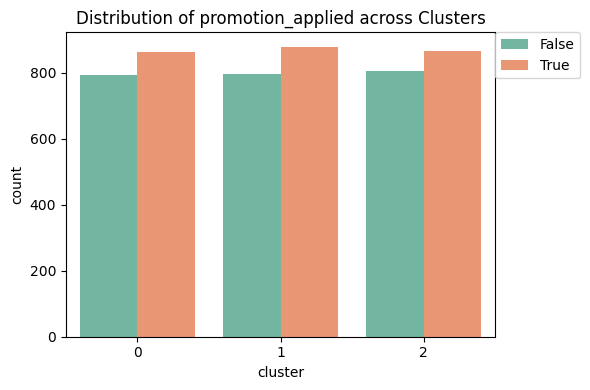

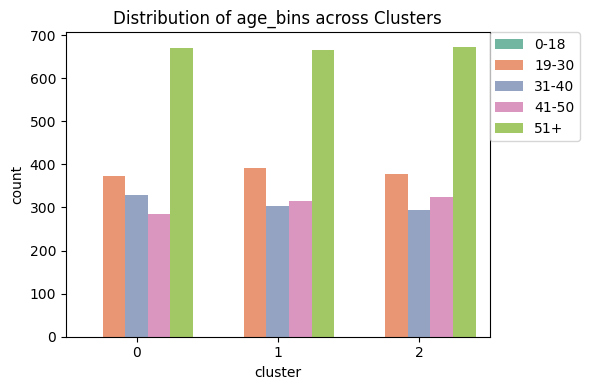

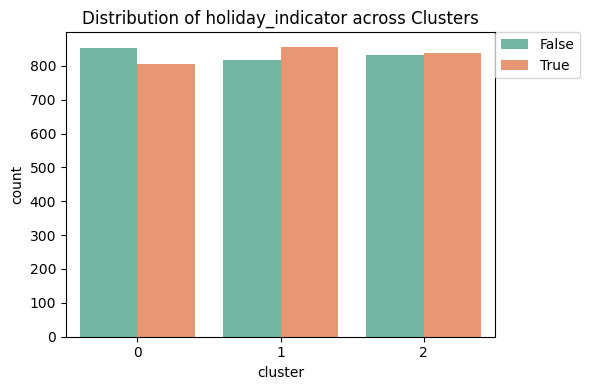

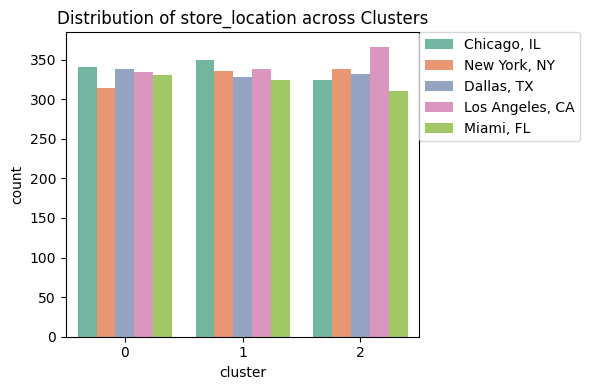

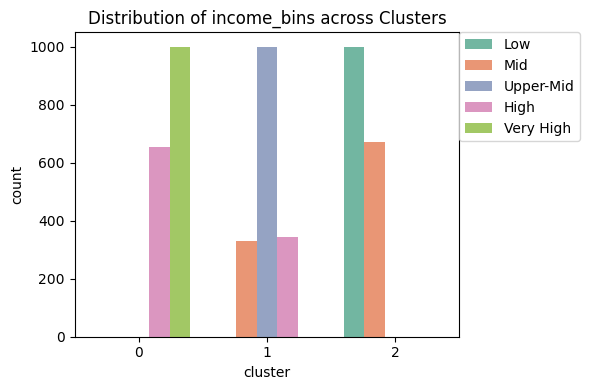

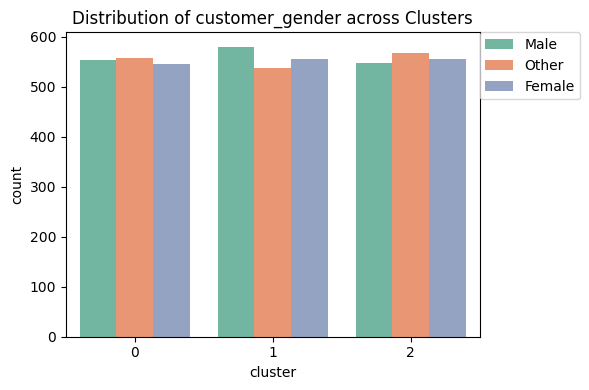

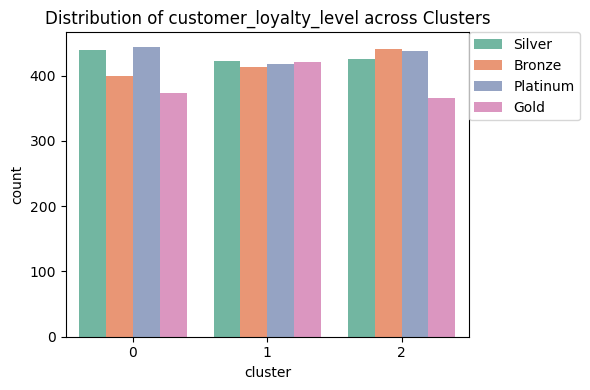

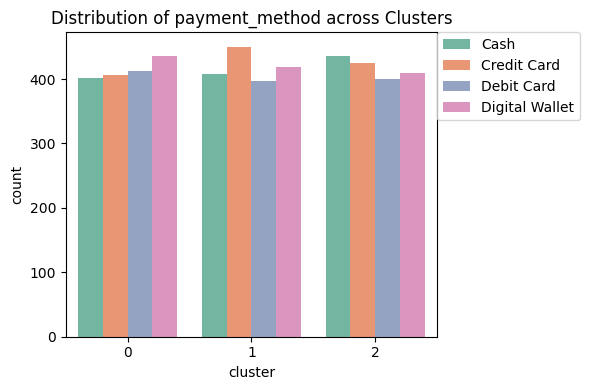

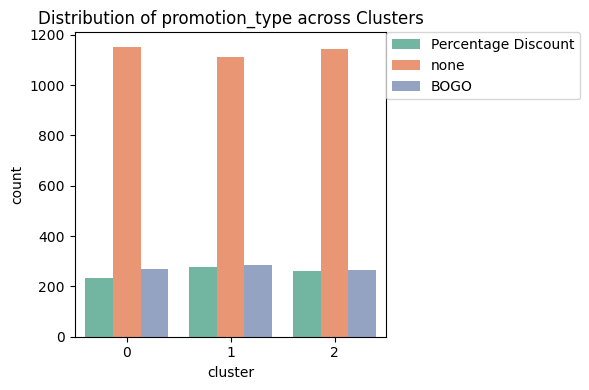

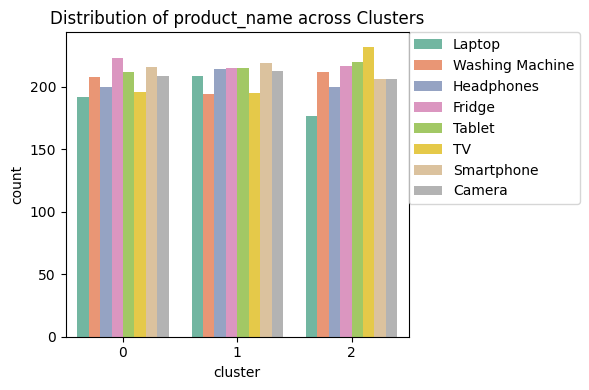

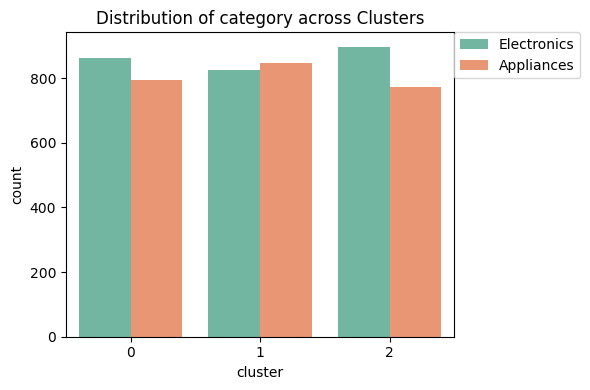

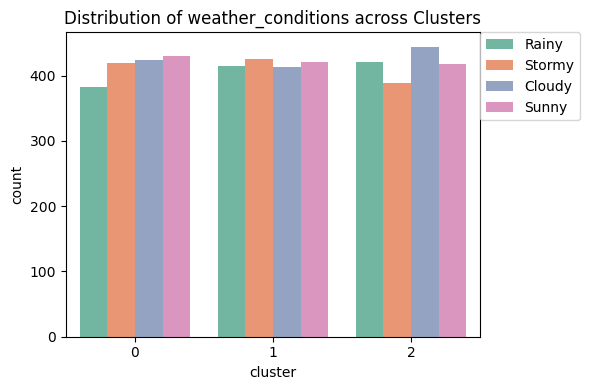

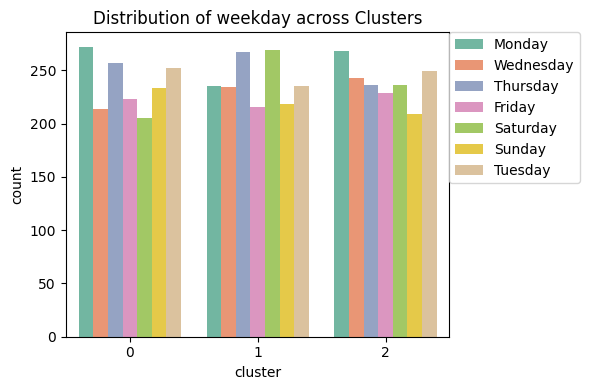

In [29]:
#Plot the distribution of categorical variables across clusters
categorical_cols = df_combined[['promotion_applied','age_bins','holiday_indicator','store_location', 'income_bins',
                                'customer_gender','customer_loyalty_level','payment_method','promotion_type','product_name',
                                'category','weather_conditions','weekday']]
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='cluster', hue=col, data=df_combined, palette='Set2')
    plt.title(f"Distribution of {col} across Clusters")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

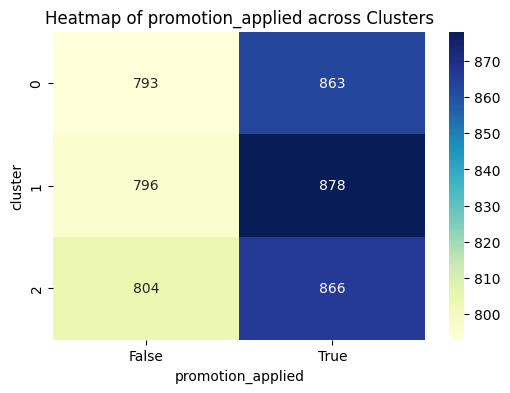

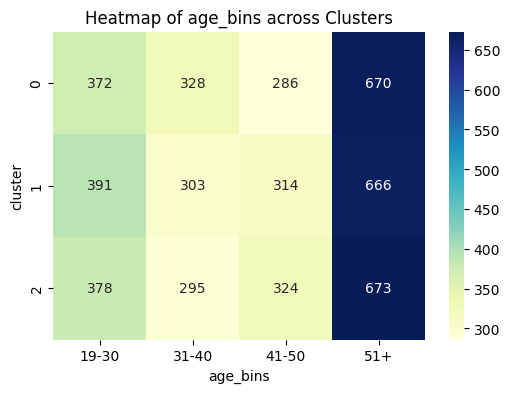

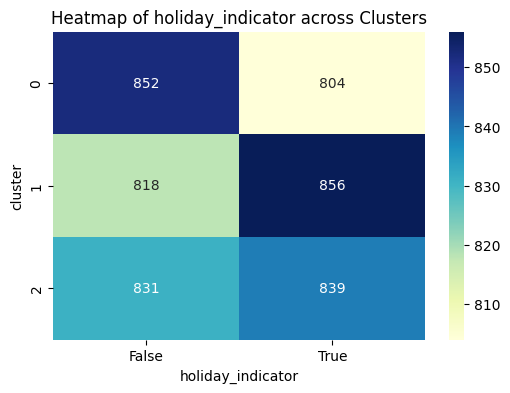

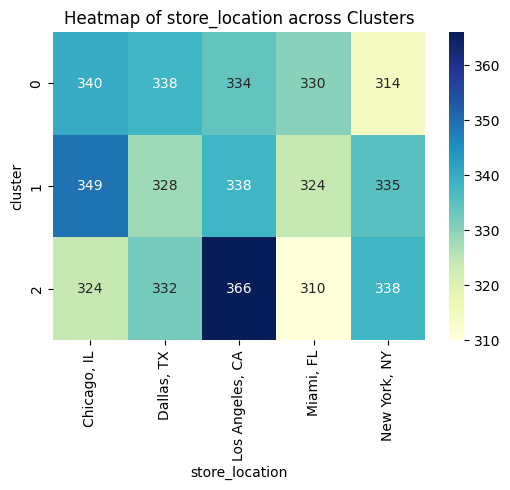

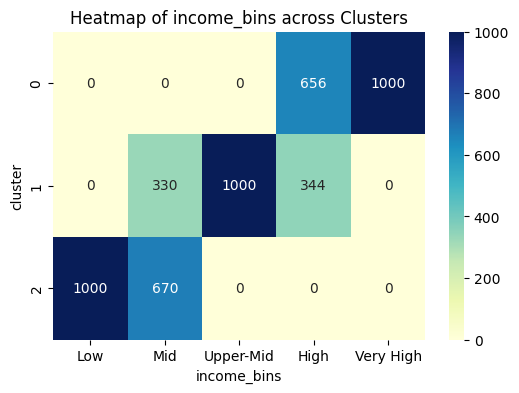

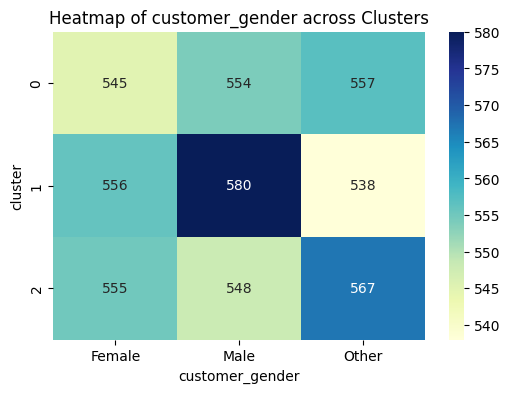

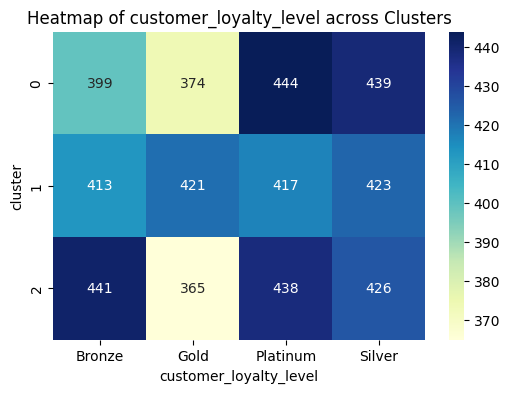

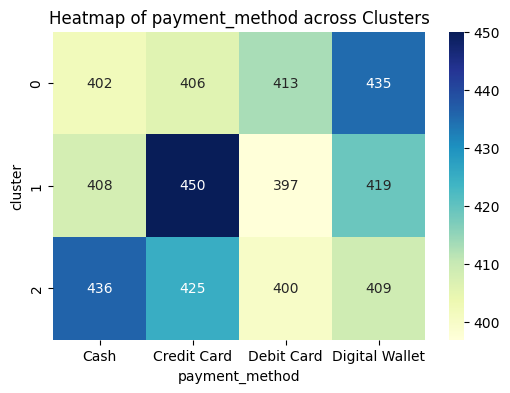

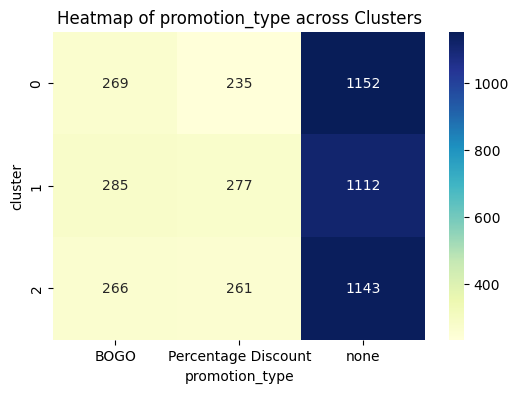

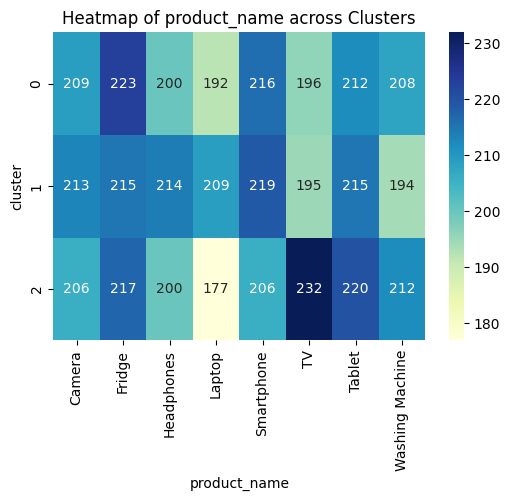

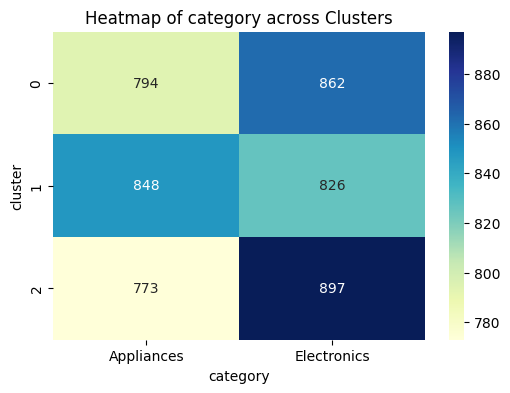

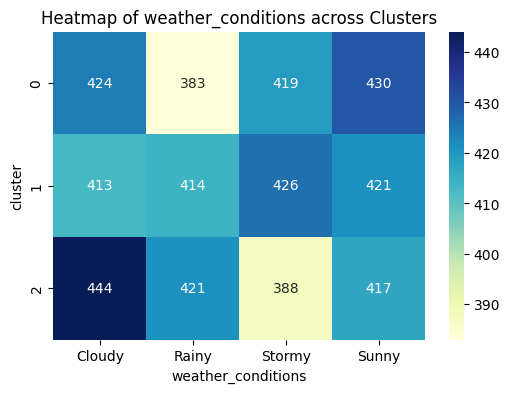

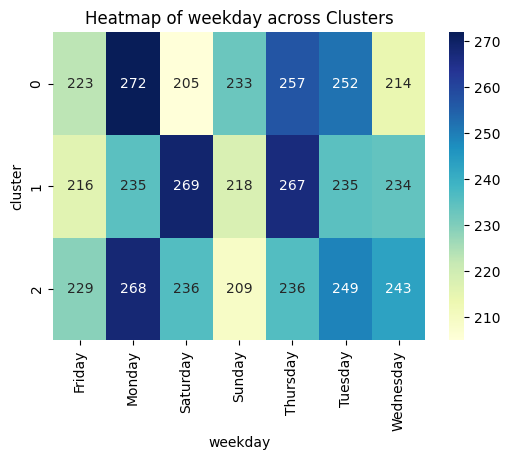

In [30]:
#Using a heatmaps, compare the frequency of categorical variables across clusters
for col in categorical_cols:
    contingency_table = pd.crosstab(df_combined['cluster'], df_combined[col])
    
    # Plot the heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f"Heatmap of {col} across Clusters")
    plt.show()

Based on inertia and Davies-Bouldin scores, three clusters were identified as optimal for segmenting customers in the K-Means model. Customer income emerged as the most significant factor influencing cluster membership. Further analysis revealed the following distinct preferences across the three clusters:

Cluster 0:
    Shopped less frequently during holidays
    Predominantly shopped at the Chicago, IL store
    Had a higher likelihood of very high income
    More commonly identified as other for gender
    Most frequently held a platinum customer loyalty status
    Preferred digital wallet payments
    Primarily purchased refrigerators
    Frequently bought products from the electronics category
    Shopped most often on Mondays
Cluster 1:
    Shopped more frequently during holidays
    Also predominantly shopped at the Chicago, IL store
    Had a higher likelihood of upper-middle income
    More frequently identified as male
    Most commonly held a silver customer loyalty status
    Preferred credit card payments
    Primarily purchased smartphones
    Frequently bought products from the appliances category
    Shopped most often on Saturdays
Cluster 2:
    Shopped more frequently during holidays
    Predominantly shopped at the Los Angeles, CA store
    Had a higher likelihood of lower income
    More commonly identified as other for gender
    Most frequently held a bronze customer loyalty status
    Preferred cash payments
    Primarily purchased televisions
    Frequently bought products from the electronics category
    Shopped most often on Mondays
    
Across all three clusters, customers displayed a strong preference for promotions. This suggests that offering targeted promotions aligned with the unique preferences of each cluster could effectively drive increased sales and engagement.